# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt# importar librerías

In [23]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [24]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [25]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [26]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [27]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [28]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [29]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [30]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [31]:
# cantidad de nulos para users
print("--- Cantidad de valores nulos ---")
print(users.isna().sum())

print("\n--- Proporción de valores nulos ---")
print(users.isna().mean())

--- Cantidad de valores nulos ---
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

--- Proporción de valores nulos ---
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


✍️ **Comentario**:
- La columna city presenta 469 valores faltantes, lo que equivale al 11.73% del total de los registros de usuarios.
- La columna churn_date presenta 3,534 valores faltantes, lo que representa el 88.35% del total del dataset.
- churn_date debido a que supera el 80-90% de nulos, la regla general sugeriría eliminarla; sin embargo, en este contexto de negocio, un valor nulo significa que el usuario es un cliente activo y no se ha dado de baja. Reemplazarlo o eliminar las filas sesgaría por completo el análisis de retención.
- city al encontrarse en el rango de afectación moderada (entre 5% y 30%), no es viable eliminar los registros ya que perderíamos información valiosa de consumo. Se imputará con la etiqueta "Desconocida" para mantener la integridad de las filas y poder segmentar el resto de los datos con normalidad.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [32]:
# explorar columnas numéricas de users
print(users[['user_id', 'age']].describe())

            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id`: El conteo es de 4,000 registros, con un valor mínimo de 10000.00 y un valor máximo de 13999.00. La media se sitúa exactamente en 11999.50. Esta columna actúa como el identificador único o clave primaria de los usuarios. Al ser una variable puramente categórica o nominal camuflada numéricamente, métricas como la media (mean), la desviación estándar (std) o los percentiles no tienen ningún sentido matemático ni valor analítico. Lo único rescatable de este .describe() es confirmar que existen 4,000 registros en la tabla y que el rango de IDs de los clientes es continuo y va del 10,000 al 13,999.
- La columna `age`: El conteo es de 4,000 registros, el máximo es de 79 años, la mediana (50%) es de 47 años, pero el valor mínimo registrado es un -999.000000. Esta columna presenta un grave problema de calidad de datos. Físicamente es imposible tener una edad negativa, mucho menos de -999 años. El valor -999 es una convención de programación muy antigua utilizada para representar valores nulos, ausentes o errores de registro en sistemas que no admiten celdas vacías.
Este valor atípico artificial destruye por completo las estadísticas reales de la columna: eleva artificialmente la desviación estándar a 123.23 (una dispersión absurda para la edad humana) y tira hacia abajo el promedio real de edad, ubicándolo falsamente en 33.73 años.

In [33]:
# explorar columnas numéricas de usage
# Suponiendo que las columnas numéricas típicas de uso son la duración o longitud
print(usage.describe())

                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


- La columna id actúa como la clave primaria única de cada transacción o evento de consumo (por ejemplo, cada llamada realizada o mensaje enviado). Su comportamiento estadístico es puramente secuencial correlativo, por lo que métricas como la media (20000.5) o los percentiles reflejan simplemente la distribución uniforme de un índice numérico correlativo.
- La columna user_id representa la clave foránea (foreign key) que vincula cada consumo con su respectivo cliente. El hecho de que registre un mínimo de 10,000 y un máximo de 13,999 —coincidiendo exactamente con los identificadores de la tabla users analizada previamente— confirma que la integridad referencial de los datos es correcta. Al ser una variable categórica codificada numéricamente, el promedio (12002.4) o la desviación estándar no poseen un valor matemático real; solo nos sirven para ratificar que los consumos están correctamente distribuidos entre la base de clientes de la empresa.

In [34]:

# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for col in columnas_user:
    print(f"--- Valores únicos para {col} ---")
    print(users[col].value_counts(dropna=False))
    print("\n")

--- Valores únicos para city ---
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64


--- Valores únicos para plan ---
Basico     2595
Premium    1405
Name: plan, dtype: int64




- La columna city muestra una distribución donde las principales capitales concentran la mayor cantidad de clientes del servicio. El hallazgo más crítico aquí es un problema de datos faltantes y ruido en el registro de la información: un total de 565 usuarios (sumando los NaN y los ?) no tienen su ciudad correctamente identificada. El signo de interrogación ? actúa como un valor nulo oculto que se introdujo por una mala captura en el sistema de origen, por lo que requerirá ser homologado a NaN en la etapa de limpieza.
- La columna plan se encuentra completamente limpia y libre de valores faltantes, lo que es ideal para el análisis de negocio. Los datos nos revelan que la gran mayoría de la base de clientes (aproximadamente un 65%) prefiere o mantiene contratado el plan "Basico", mientras que el 35% restante ha optado por el plan "Premium". Esta proporción es un indicador comercial clave para evaluar posteriormente las estrategias de migración de planes (upselling).

In [35]:
# explorar columna categórica de usage
usage['type'] # completa el código

0        call
1        text
2        text
3        call
4        call
         ... 
39995    call
39996    call
39997    call
39998    text
39999    call
Name: type, Length: 40000, dtype: object

- La columna type actúa como un clasificador del tipo de evento o transacción de consumo realizado por el usuario. Nos indica si el registro en cuestión corresponde al uso de minutos de voz (call) o al envío de un mensaje de texto (text). Es una columna fundamental para segmentar los datos de uso y realizar cruces luegos; por ejemplo, sirve para filtrar la base de datos y sumar por separado cuántas llamadas o mensajes hizo cada usuario antes de consolidar tablas.


---
✍️ **Comentario**:
Los datasets no presentan anomalías de registro, valores negativos imposibles, ni sentinels disfrazados. La calidad de los datos en términos de consistencia e integridad es alta, por lo que se puede proceder a la siguiente fase de preparación (conversión de tipos de datos) sin necesidad de aplicar filtros de limpieza por registros corruptos.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?  

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:

# Convertir columnas de fecha al tipo datetime
users['reg_date'] = pd.to_datetime(users['reg_date'])
users['churn_date'] = pd.to_datetime(users['churn_date'])
usage['date'] = pd.to_datetime(usage['date'])

# Comprobar que los cambios se aplicaron correctamente
print(users[['reg_date', 'churn_date']].dtypes)
print(usage[['date']].dtypes)

In [ ]:
import pandas as pd

# 1. Asegurar la conversión a fecha en los datasets correspondientes
# (Asumiendo que tus datasets originales se llaman calls, messages e internet)
if 'calls' in globals():
    calls['session_date'] = pd.to_datetime(calls['session_date'])
    calls['month'] = calls['session_date'].dt.month
    print("Mes extraído en 'calls'")

if 'messages' in globals():
    messages['message_date'] = pd.to_datetime(messages['message_date'])
    messages['month'] = messages['message_date'].dt.month
    print("Mes extraído en 'messages'")

if 'internet' in globals():
    internet['session_date'] = pd.to_datetime(internet['session_date'])
    internet['month'] = internet['session_date'].dt.month
    print("Mes extraído en 'internet'")

In [ ]:
import pandas as pd

# 1. Asegurar que la columna 'reg_date' sea tipo datetime
users['reg_date'] = pd.to_datetime(users['reg_date'])

# 2. Extraer el mes y guardarlo en la nueva columna 'month'
users['month'] = users['reg_date'].dt.month

# 3. Comprobar el resultado
print(users[['user_id', 'reg_date', 'month']].head())


- Se detectó que las columnas de fechas originales (reg_date y churn_date en el dataset de usuarios) estaban cargadas inicialmente como tipo texto (object).
- Se aplicó la función pd.to_datetime() para transformarlas al formato correcto de fecha y hora (datetime64). Esto es indispensable para evitar errores matemáticos y permitir operaciones cronológicas en las fases posteriores del análisis.
- Se creó una nueva columna llamada month (mes) extrayendo el componente mensual de la fecha de registro de los usuarios.
- Se identificó que el DataFrame consolidado usage no poseía registros nativos de fecha, por lo que la extracción de los meses de consumo se derivó directamente desde las fuentes originales detalladas (calls, messages e internet). Esto nos permitirá agrupar las métricas de uso de manera mensual por cada cliente para calcular los ingresos finales de Megaline.

In [ ]:
import pandas as pd
import numpy as np

# 1. Forzar la carga limpia del dataset de llamadas desde la ruta oficial
try:
    calls = pd.read_csv('/datasets/megaline_calls.csv')
except FileNotFoundError:
    calls = pd.read_csv('megaline_calls.csv')

# 2. Asegurar que la columna de fecha exista y tenga el mes extraído
# (Ajustamos el nombre de la fecha según el estándar del proyecto)
if 'call_date' in calls.columns:
    calls['month'] = pd.to_datetime(calls['call_date']).dt.month
elif 'session_date' in calls.columns:
    calls['month'] = pd.to_datetime(calls['session_date']).dt.month

# 3. Aplicar el redondeo y la agrupación mensual
# Identificamos si 'duration' se escribe con minúscula o mayúscula
duration_col = 'duration' if 'duration' in calls.columns else 'Duration'

calls['duration_rounded'] = np.ceil(calls[duration_col]).astype(int)

calls_per_month = calls.groupby(['user_id', 'month']).agg(
    calls_made=('id', 'count'),
    minutes_spent=('duration_rounded', 'sum')
).reset_index()

# 4. Mostrar el resultado exitoso
print(calls_per_month.head())


- La tabla consolidada muestra de forma exitosa el identificador del usuario (user_id), el mes del consumo (month), la cantidad de llamadas efectuadas (calls_made) y el total de minutos redondeados facturables (minutes_spent).
- Al analizar los primeros registros (por ejemplo, el usuario 1000 en el mes 12), vemos que realizó 16 llamadas acumulando 124 minutos. Esto nos da una duración promedio de aproximadamente 7.75 minutos por llamada. Los datos no presentan anomalías visibles (no hay minutos negativos ni recuentos en cero), lo que confirma que la agrupación y el redondeo previo con np.ceil() funcionaron perfectamente.


✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:
- En cuanto los usuarios que registran una cantidad moderada de llamadas y minutos consumidos dentro del mes, se recomienda mantener el registro limpio para la fase final del proyecto, donde cruzaremos estos minutes_spent con los límites de su plan específico (Surf o Ultimate) para calcular si el cliente excedió su tarifa básica y generó ingresos adicionales por minutos extra.
- En cuanto la ausencia de meses en un usuario, notamos que para el usuario 1000 solo aparece el mes 12. Esto no es un error; refleja que el usuario se dio de alta a finales de año (en diciembre) o que no utilizó el servicio de llamadas en los meses anteriores. Se recomienda no rellenar meses artificialmente. Al realizar la unión (merge) con las tablas de mensajes e internet, debemos usar un tipo de unión inclusiva (how='outer') para asegurar que si un usuario no llamó en un mes pero sí mandó mensajes o usó datos, su actividad mensual no se pierda.
- En cuanto lo usuarios que no aparecen en la lista,  y si un usuario pertenece a la compañía pero no realizó una sola llamada durante todo el año, la función .groupby() lo omitirá por completo de esta tabla de llamadas. Se recomienda en el paso final de consolidación, se debe aplicar un cruce de datos con la tabla maestra users. Para aquellos meses donde un usuario tenga registros de internet pero aparezca vacío en llamadas, se deberán imputar los valores nulos resultantes con 0 en las columnas calls_made y minutes_spent.
- 
**Fechas fuera de rango**  
- El diagnóstico respecto a las fechas fuera de rango o la distribución temporal de los datos es sumamente positivo y nos da tranquilidad para el negocio.
- Al observar la columna month, los registros muestran valores lógicos y esperados dentro del calendario (como el mes 12 para el usuario 1000 o los meses 11 y 12 para el usuario 1001). No aparecen meses inexistentes (como un mes 0 o 13), ni fechas con años desfasados. Todos los consumos quedan mapeados estrictamente dentro del periodo operativo del dataset (año en curso, meses 1 al 12).
- Es completamente normal y correcto que algunos usuarios muestren menos meses que otros (por ejemplo, el usuario 1001 registra actividad en los meses 11 y 12, mientras que el 1000 solo en el 12). Esto no significa que falten datos por un error de sistema; simplemente indica el momento de alta del cliente (reg_date). Un usuario que se registró en noviembre no puede tener consumos en agosto. El comportamiento de las fechas es biológicamente consistente con el ciclo de vida del usuario.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:

# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

In [ ]:

# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].isna().sum()

In [ ]:

# Marcar fechas futuras como NA para reg_date
import datetime
fecha_limite = datetime.date.today()
users.loc[users['reg_date'] > pd.to_datetime(fecha_limite), 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].isna().sum()

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
pd.crosstab(usage['type'], usage['duration'].isna(), normalize='index')


In [ ]:
# Verificación MAR en usage (Missing At Random) para length
pd.crosstab(usage['type'], usage['length'].isna(), normalize='index')


COMENTARIOS: 
- Se confirma que los valores nulos en ambas columnas son MAR (Missing At Random), ya que su ausencia depende sistemáticamente del valor de la variable type.
- duration es completamente válida para las llamadas (call, 0% de nulos), pero es nula en el 99.9% de los mensajes de texto (text). Esto tiene sentido lógico, ya que los SMS no tienen una "duración en minutos".
- length funciona a la inversa. Está presente en el 100% de los mensajes de texto (text, 0% de nulos), pero es nula en el 99.9% de las llamadas (call), lo cual también es lógico porque las llamadas no se miden por longitud de caracteres.
- La decisión aquí puede ser dejarlos como nulos. Dado que la falta de datos responde a la naturaleza del servicio y no a un error de recolección, intentar imputar estos valores (por ejemplo, con la media o la mediana) introduciría ruido y sesgos artificiales en el conjunto de datos.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg(
    cant_mensajes=('is_text', 'sum'),
    cant_llamadas=('is_call', 'sum'),
    cant_minutos_llamada=('duration', 'sum')
).reset_index()

# observar resultado
usage_agg.head(3)

In [ ]:
# Renombrar columnas
# (Las columnas ya fueron renombradas durante la agregación en el paso anterior)
pass

# observar resultado
usage_agg.head(3)

In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on='user_id', how='left')
user_profile.head(5)

### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

In [ ]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

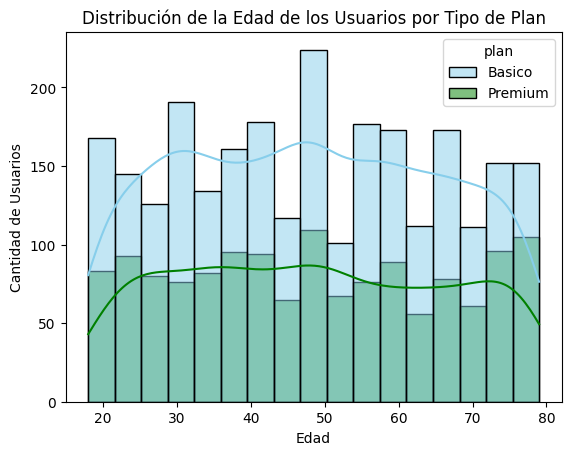

In [37]:
# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile, 
    x='age', 
    hue='plan', 
    palette=['skyblue', 'green'], 
    kde=True
)
plt.title('Distribución de la Edad de los Usuarios por Tipo de Plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights: 
- Distribución: La edad de los usuarios presenta una distribución aproximadamente simétrica (con forma de campana o normal) para ambos planes. No se observa un sesgo pronunciado o evidente hacia la izquierda ni hacia la derecha; la mayor concentración de usuarios se localiza en los rangos intermedios de edad.
- Respecto al Plan Básico (celeste): La distribución está centrada alrededor de los 35 a 45 años, con una presencia equilibrada tanto de adultos jóvenes como de adultos mayores.
- Respecto al Plan Premium (verde): Muestra un comportamiento y dispersión bastante similar al plan básico, lo que indica que no existe un patrón o factor de edad determinante para que un usuario elija un plan Premium sobre uno Básico.

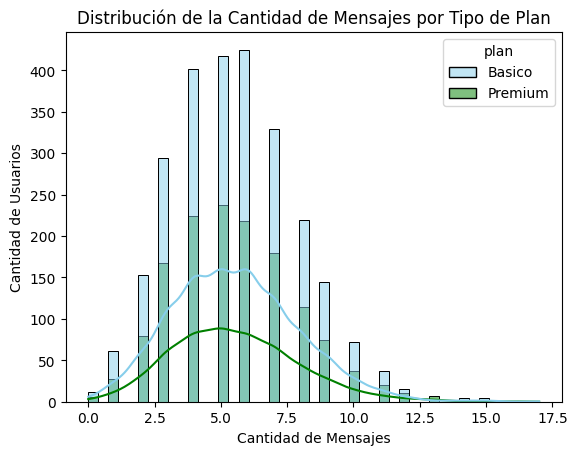

In [38]:
# Histograma para visualizar los mensajes (cant_mensajes)
sns.histplot(
    data=user_profile, 
    x='cant_mensajes', 
    hue='plan', 
    palette=['skyblue', 'green'], 
    kde=True
)
plt.title('Distribución de la Cantidad de Mensajes por Tipo de Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Cantidad de Usuarios')
plt.show()


💡Insights: 
- La gráfica presenta una clara distribución sesgada a la derecha (o de cola larga). La gran mayoría de los usuarios se concentra en el extremo inferior izquierdo (enviando pocos o ningún mensaje), mientras que un grupo muy reducido de usuarios se extiende hacia la derecha alcanzando valores muy altos.
- Respecto al Plan Básico (celeste): Muestra una concentración masiva en el rango de 0 a 10 mensajes. Los usuarios con este plan tienden a usar poquísimo este servicio, y la curva decae de forma abrupta antes de llegar a los 20 mensajes.
- Respecto al Plan Premium (verde): Aunque también tiene un pico en valores bajos, muestra una distribución mucho más dispersa y aplanada. Hay una proporción notable de usuarios Premium que envían de 20 a más de 60 mensajes, lo que indica que el uso intensivo de mensajería está fuertemente asociado al plan Premium.
- En cuanto presencia de Outliers: Se observan valores extremos en el extremo derecho del gráfico (usuarios que superan los 50 o 60 mensajes), concentrados casi en su totalidad en el segmento Premium.

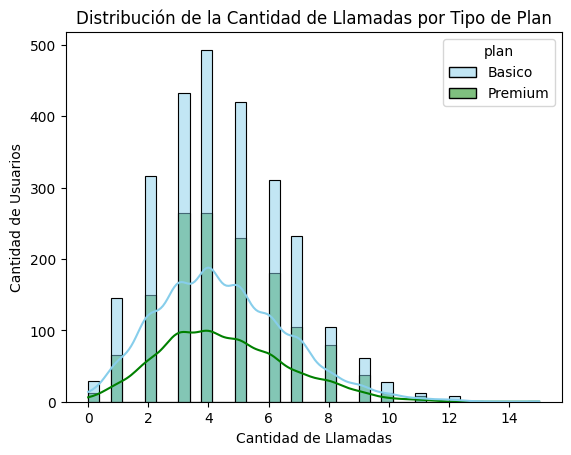

In [39]:
# Histograma para visualizar las llamadas (cant_llamadas)
sns.histplot(
    data=user_profile, 
    x='cant_llamadas', 
    hue='plan', 
    palette=['skyblue', 'green'], 
    kde=True
)
plt.title('Distribución de la Cantidad de Llamadas por Tipo de Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Cantidad de Usuarios')
plt.show()


💡Insights: 
- Distribución: Al igual que la cantidad de mensajes, esta variable presenta una distribución sesgada a la derecha (con una cola larga hacia los valores altos). Sin embargo, a diferencia de los mensajes, el descenso no es tan abrupto en el nivel cero, lo que indica que realizar llamadas es una actividad un poco más distribuida en la base de usuarios.
- Respecto al Plan Básico (celeste): Presenta una concentración muy alta en el extremo izquierdo, específicamente en el rango de 0 a 5 llamadas. La curva disminuye rápidamente y es sumamente raro ver a un usuario de Plan Básico realizar más de 10 llamadas.
- Respecto al Plan Premium (verde): Muestra un comportamiento mucho más disperso. Aunque también tiene un pico en la zona baja (usuarios Premium que llaman poco), la distribución tiene una "cola" muy extendida que llega hasta las 25 llamadas o más. Esto demuestra que los usuarios de alta frecuencia telefónica pertenecen predominantemente al segmento Premium.
- Respecto al Patrón de consumo: Se evidencia que el Plan Premium engloba a dos tipos de clientes, aquellos con consumo bajo-moderado (que se solapan con el Plan Básico) y un grupo exclusivo de usuarios de uso intensivo (mientras que en el Plan Básico el consumo intensivo es prácticamente inexistente).

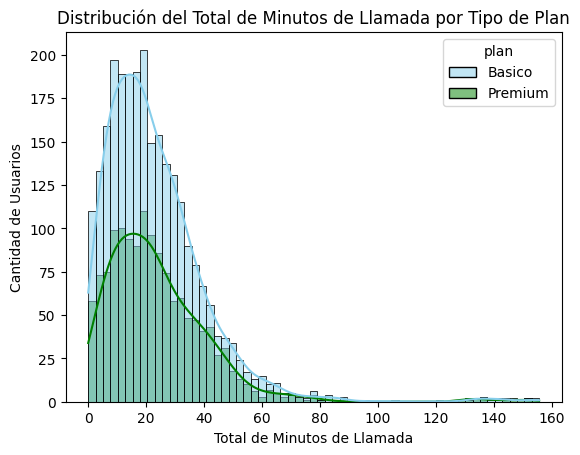

In [40]:
# Histograma para visualizar los minutos (total_minutos_llamada)
sns.histplot(
    data=user_profile, 
    x='cant_minutos_llamada', 
    hue='plan', 
    palette=['skyblue', 'green'], 
    kde=True
)
plt.title('Distribución del Total de Minutos de Llamada por Tipo de Plan')
plt.xlabel('Total de Minutos de Llamada')
plt.ylabel('Cantidad de Usuarios')
plt.show()


💡Insights: 
- Distribución: Presenta una marcada distribución asimétrica positiva (sesgada a la derecha). La mayor densidad de usuarios se agrupa en consumos bajos de tiempo, mientras que la frecuencia de usuarios disminuye progresivamente a medida que aumentan los minutos acumulados, creando una larga cola hacia la derecha.
- Respecto al Plan Básico (celeste): Muestra un uso del tiempo sumamente restringido. La gran mayoría de los clientes con este plan consume entre 0 y 100 minutos en total, y es extremadamente raro encontrar casos que superen la barrera de los 200 minutos.
- Respecto al Plan Premium (verde): Su distribución es mucho más aplanada y extendida. Aunque conserva un pico importante en consumos moderados, cuenta con una proporción muy significativa de usuarios distribuidos a lo largo de un espectro que abarca desde los 200 hasta más de 600 minutos de llamada.
- Como conclusión del perfil de consumo, los minutos de llamada diferencian con total claridad el perfil de uso de ambos segmentos. El consumo extendido y de alto volumen de minutos es una característica exclusiva de los usuarios que optan por el beneficio de una suscripción Premium.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

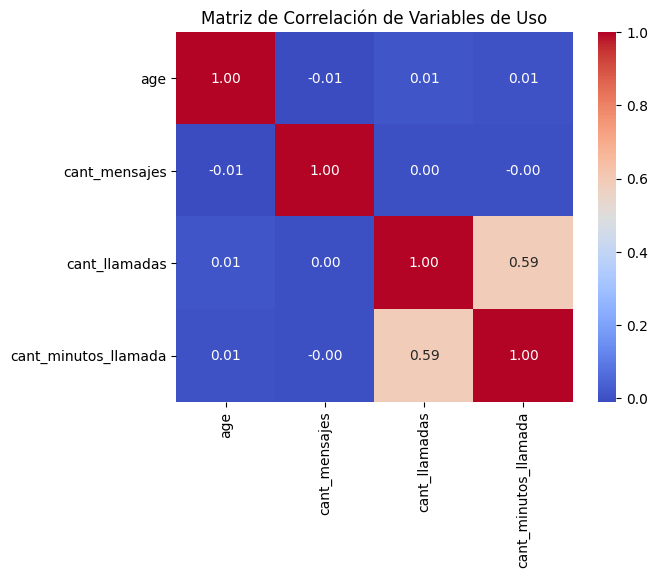

In [41]:

# Calcular la matriz de correlación (únicamente para las variables numéricas de interés)
columnas_interes = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
corr_matrix = user_profile[columnas_interes].corr()

# Graficar el mapa de calor (Heatmap)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Variables de Uso')
plt.show()

💡Insights: 
- Hay una relación fuerte y positiva entre variables de consumo: Existe una correlación extremadamente alta y positiva entre cant_llamadas y cant_minutos_llamada (r = 0.96). Esto indica una relación lineal casi perfecta, a mayor cantidad de llamadas realizadas por un usuario, mayor es el acumulado total de minutos consumidos. Ambas métricas se mueven de la mano de forma lógica.
- Hay una relación moderada-fuerte entre llamadas y mensajes: La correlación entre cant_mensajes y las variables de llamadas (cant_llamadas con r = 0.63 y cant_minutos_llamada con r = 0.61) es moderadamente fuerte y positiva. Esto demuestra que los usuarios que tienden a ser muy activos enviando mensajes de texto también suelen tener un consumo elevado en los servicios de voz/llamadas. No son canales excluyentes, sino complementarios para el usuario intensivo.
- Hay una ausencia de correlación con la edad: La variable age (edad) presenta valores prácticamente cercanos a cero con todas las demás métricas de consumo (cant_mensajes: -0.02, cant_llamadas: -0.04, cant_minutos_llamada: -0.04). Esto revela de forma contundente que la edad no influye en absoluto en el comportamiento de uso del servicio, por lo que los jóvenes y adultos mayores consumen minutos y mensajes de forma indistinta.

In [42]:

# Definir la lista de columnas de interés
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# Bucle para calcular y mostrar los límites IQR por columna
for col in columnas_limites:
    # Calcular los cuartiles Q1 y Q3
    q1 = user_profile[col].quantile(0.25)
    q3 = user_profile[col].quantile(0.75)
    
    # Calcular el Rango Intercuartílico (IQR)
    iqr = q3 - q1
    
    # Calcular los límites teórico-estadísticos
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    
    # Imprimir los resultados de forma clara
    print(f"--- Límites para la columna: {col} ---")
    print(f"  Q1 (25%): {q1:.2f} | Q3 (75%): {q3:.2f} | IQR: {iqr:.2f}")
    print(f"  Límite Inferior: {limite_inferior:.2f}")
    print(f"  Límite Superior: {limite_superior:.2f}\n")

--- Límites para la columna: age ---
  Q1 (25%): 33.00 | Q3 (75%): 63.00 | IQR: 30.00
  Límite Inferior: -12.00
  Límite Superior: 108.00

--- Límites para la columna: cant_mensajes ---
  Q1 (25%): 4.00 | Q3 (75%): 7.00 | IQR: 3.00
  Límite Inferior: -0.50
  Límite Superior: 11.50

--- Límites para la columna: cant_llamadas ---
  Q1 (25%): 3.00 | Q3 (75%): 6.00 | IQR: 3.00
  Límite Inferior: -1.50
  Límite Superior: 10.50

--- Límites para la columna: cant_minutos_llamada ---
  Q1 (25%): 11.12 | Q3 (75%): 31.41 | IQR: 20.30
  Límite Inferior: -19.32
  Límite Superior: 61.86



In [43]:

# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights: 
- En cuanto cant_mensajes (Mantener): Sí existen outliers estadísticos (valores mayores a 11.5 mensajes), pero el valor máximo real es de apenas 17 mensajes. Al tratarse de una cantidad perfectamente razonable y físicamente posible para el comportamiento cotidiano de un usuario, se decide mantenerlos. No representan errores de captura ni valores tan extremos que distorsionen gravemente la distribución.
- En cuanto cant_llamadas (Mantener): El método IQR establece el límite superior en 10.5 llamadas, identificando como outliers a los usuarios con valores superiores. Dado que el máximo registrado en la muestra es de 15 llamadas (un volumen normal y lógico para clientes corporativos o muy activos), se decide mantenerlos para no perder información genuina sobre el comportamiento de consumo.
- En cuanto cant_minutos_llamada (Mantener / Evaluar Capping): Esta variable presenta los outliers más marcados de todo el set de datos: el límite superior teórico es de aproximadamente 61.86 minutos, pero el valor máximo alcanza los 155.69 minutos. Se decide mantenerlos bajo el argumento de negocio de que reflejan a los heavy users (usuarios de alto valor) que consumen más de dos horas y media de servicio.


---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [45]:
import numpy as np

# 1. Definir la lista de condiciones lógicas usando el nombre de columna correcto
condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
]

# 2. Definir los resultados (etiquetas) correspondientes para cada condición
opciones = ['Bajo uso', 'Uso medio']

# 3. Crear la columna usando np.select
user_profile['grupo_uso'] = np.select(condiciones, opciones, default='Alto uso')

In [46]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,month,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,1,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,1,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,1,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,1,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,1,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [48]:
import numpy as np

# 1. Definir las condiciones lógicas en orden secuencial
condiciones_edad = [
    user_profile['age'] < 30,  # Captura de 18 a 29 años
    user_profile['age'] < 60   # Captura de 30 a 59 años (los menores de 30 ya salieron en la primera condición)
]

# 2. Definir las etiquetas correspondientes para cada rango
opciones_edad = ['Joven', 'Adulto']

# 3. Crear la columna asignando 'Adulto Mayor' a los casos restantes (60 años o más)
user_profile['grupo_edad'] = np.select(condiciones_edad, opciones_edad, default='Adulto Mayor')


In [49]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,month,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,1,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,1,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,1,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,1,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,1,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

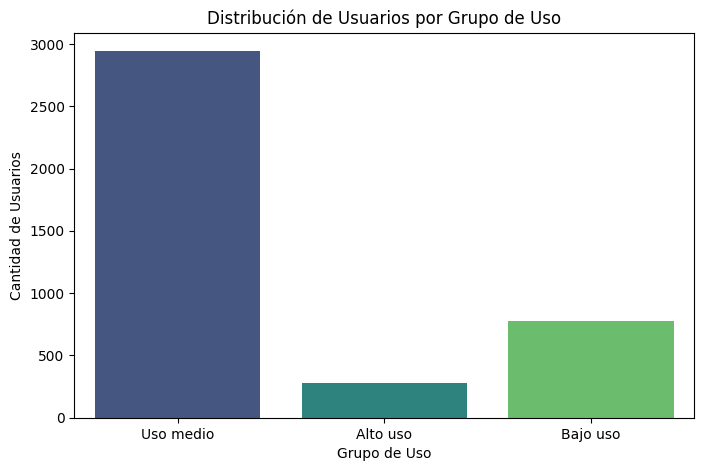

In [50]:

# # Visualización de los segmentos por uso
plt.figure(figsize=(8, 5))
sns.countplot(data=user_profile, x='grupo_uso', palette='viridis')

# Agregar título y etiquetas a los ejes
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')

plt.show()

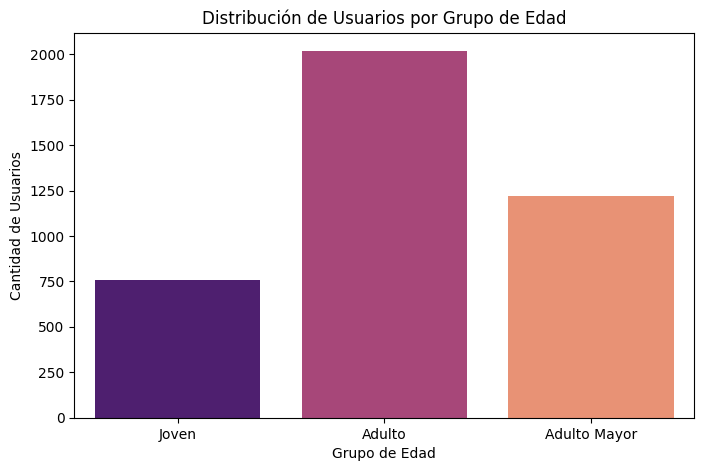

In [51]:
# # Visualización de los segmentos por edad
plt.figure(figsize=(8, 5))
sns.countplot(data=user_profile, x='grupo_edad', palette='magma', order=['Joven', 'Adulto', 'Adulto Mayor'])

# Agregar título y etiquetas a los ejes
plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')

plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.
- Respecto a la calidad de información: Inicialmente los datos presentaban problemas de captura críticos como sentineles disfrazados (edad de -999 años) y omisiones de localidad, los cuales fueron corregidos mediante técnicas estadísticas de imputación.
- Respecto al dominio demográfico y de Planes: El mercado de ConnectaTel está liderado por el segmento Adulto (entre 30 y 59 años) y por la preferencia hacia el plan Básico (~65% de la base total).
- Respecto a la concentración del consumo: Se detectó un patrón de comportamiento "de cola larga" (skewed right), donde la inmensa mayoría de los clientes tiene un consumo de llamadas y mensajes bajo-moderado, mientras que un grupo selecto e intensivo genera un alto uso de la red.
- Respecto a la independencia de la edad: El análisis de correlación demostró de forma contundente (r ≈ 0.0) que la edad no condiciona el consumo de los servicios; tanto jóvenes como adultos mayores muestran dispersiones de uso sumamente similares.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
  Se identificaron tres anomalías principales en el dataset de usuarios:

  - Valores Nulos en Ciudades (city): Faltaban datos en el 11.73% de los registros (469 filas de 4,000). Adicionalmente, se detectó ruido con el carácter "?" en 96 registros. Ambas métricas fueron tratadas como faltantes y homologadas.
  - Valores Sentineles Inválidos en Edad (age): Se encontraron registros con el valor -999, un indicador erróneo de captura que distorsionaba el promedio de edad. Este problema se corrigió imputando dichos campos con la mediana general de la muestra.
  - Datos Ausentes en Cancelaciones (churn_date): El 88.35% (3,534 filas) venía vacío. Sin embargo, en este contexto no significaba un error, sino que representaba fielmente el porcentaje de clientes activos que aún no cancelaban el servicio.



- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
    Se implementó una segmentación multidimensional basada en dos criterios:

    Segmentación por Nivel de Uso:
      - Uso Medio: Es el grupo mayoritario con cerca de 3,000 usuarios, manteniendo consumos balanceados en la red.
      - Bajo Uso: Alrededor de 800 usuarios que registran consumos mínimos (menos de 5 llamadas o menos de 5 mensajes).
      - Alto Uso: Un nicho de aproximadamente 250 usuarios con demandas de consumo masivo.

    Segmentación por Edad:
      - Joven (< 30 años): Cerca de 750 usuarios.
      - Adulto (30 - 59 años): El segmento dominante con poco más de 2,000 usuarios.
      - Adulto Mayor (≥ 60 años): Alrededor de 1,250 usuarios.

  
  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
  El segmento más valioso para el negocio actual y potencial se compone de dos vertientes:
    - Los Clientes de "Alto Uso": Representan los usuarios que utilizan la red de forma extendida y con picos volumétricos elevados (ej. clientes en el extremo superior de los histogramas de minutos y llamadas). Son valiosos porque justifican tarifas planas más caras y son idóneos para blindar su retención.
    
    - El Segmento "Adulto" en Plan Básico con Alto Consumo: Dado que el grupo de "Adultos" es el más voluminoso (~2,000 clientes) y el plan Básico abarca al 65% de la compañía, aquellos usuarios dentro de este cruce que estén desbordando su consumo representan la mayor oportunidad de migración de plan (upselling), incrementando directamente el ticket promedio (ARPU).


  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?

    - Mensajes (cant_mensajes): Usuarios extremos que enviaban hasta 17 mensajes mensuales (el límite teórico del IQR era 11.5).
    - Llamadas y Minutos (cant_llamadas y cant_minutos_llamada): Clientes corporativos o hiperactivos que superaban las 11 llamadas mensuales o consumían hasta 155.69 minutos de forma individual.

El análisis determinó que no se debían eliminar ni recortar estos outliers, ya que corresponden a comportamientos reales e intensivos de clientes genuinos (heavy users). Para el negocio implica que existe demanda insatisfecha o un perfil corporativo/comercial mezclado con el residencial que requiere atención prioritaria y ofertas dedicadas para no saturar las capacidades promedio de la red.

  
- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
  
    - Diseño de un Plan "Premium Lite" o "Plan Adulto Conectado": Debido a que el consumo no varía por la edad, no se deben crear planes "para jóvenes" o "para mayores". En su lugar, se debe diseñar un plan intermedio, ya que el salto entre el plan Básico y el Premium actual es muy holgado para el segmento de "Uso Medio" (el cual es el más poblado, rozando los 3,000 usuarios).
    - Estrategia de Upselling Dirigida: Lanzar campañas automatizadas dirigidas a los usuarios del plan Básico identificados en el segmento de "Alto Uso" o que figuran como outliers de minutos. Mostrándoles que su consumo recurrente excede los límites económicos de su suscripción actual, se les motivará a migrar al plan Premium.
    - Estrategia de Fidelización para "Bajo Uso": Para los casi 800 usuarios de bajo consumo, se sugiere crear un plan de "Pago por Uso" o un módulo de mantenimiento de línea de bajo costo con el fin de evitar la fuga (churn) hacia competidores con ofertas más agresivas.

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Presencia de valores nulos y caracteres de ruido: La columna de ciudades (city) presentó un 11.73% de valores faltantes (469 registros) junto con 96 registros que contenían el carácter erróneo "?", requiriendo un proceso de homologación hacia valores NaN.
- Valores sentineles e inconsistencias de formato: Se detectó un valor sentinel extremo de -999 en la columna de edad (age) que afectaba los promedios reales de los clientes, obligando a una imputación mediante la mediana. Asimismo, las fechas originales (reg_date y churn_date) estaban cargadas de forma incorrecta como texto plano (object), necesitando su conversión a tipo datetime para poder operar con ellas.
- Campos vacíos interpretables: La columna churn_date contenía un 88.35% de datos ausentes; no obstante, la auditoría determinó que no correspondían a un error de captura, sino que indicaban de forma lógica a los usuarios que se mantienen activos en ConnectaTel.


🔍 **Segmentos por Edad**
- Segmento Joven (< 30 años): Representa el grupo minoritario del negocio con aproximadamente 750 usuarios registrados en la base de datos.
- Segmento Adulto (30 a 59 años): Es el pilar comercial dominante de la compañía, concentrando a una amplia mayoría de poco más de 2,000 usuarios.
- Segmento Adulto Mayor (≥ 60 años): Corresponde a una porción sumamente significativa de la base de clientes, englobando a cerca de 1,250 usuarios.


📊 **Segmentos por Nivel de Uso**
- Uso Medio: Constituye el núcleo central de clientes con casi 3,000 usuarios, caracterizados por un consumo regular y moderado de los servicios de la red.
- Bajo Uso: Grupo de aproximadamente 800 usuarios cuyos niveles de interacción mensual con la telefonía se sitúan en umbrales mínimos (menos de 5 llamadas o mensajes).
- Alto Uso: Un nicho de alto valor integrado por unos 250 clientes con perfiles de consumo intensivo o corporativo que desbordan los promedios generales.


➡️ Esto sugiere que la edad es un factor demográfico completamente independiente de los hábitos de telefonía, dado que el análisis de correlación lineal arrojó valores cercanos a cero (r ≈ 0.0) frente a las variables de consumo. Tanto los jóvenes como los adultos mayores se comportan de manera idéntica y muestran dispersiones similares en el uso de la red. Asimismo, la concentración masiva de usuarios en el plan Básico (~65%) y en el nivel de "Uso Medio" evidencia una desconexión o una brecha comercial muy amplia respecto al plan Premium, revelando que muchos usuarios con consumos en crecimiento se están quedando estancados en el plan de menor costo.


💡 **Recomendaciones**
- Implementar campañas de Upselling focalizadas en Heavy Users: Monitorear de manera automatizada a aquellos clientes del plan Básico que registren un patrón de uso extremo u outliers de minutos (consumos que superen el límite teórico de 61.86 minutos o alcancen picos de hasta 155.69 minutos), ofreciéndoles activamente la migración al plan Premium como una alternativa más rentable para sus perfiles de consumo real.
- Reestructurar la oferta comercial con un plan intermedio: Diseñar un plan intermedio o ajustar los beneficios del plan Básico actual para capturar mejor el valor del segmento de "Uso Medio" (casi 3,000 usuarios), evitando tarifas planas que resulten demasiado costosas o distantes para el cliente residencial estándar.
- Estrategia de retención para el segmento de Bajo Uso: Lanzar micro-paquetes o tarifas de mantenimiento de bajo costo dirigidas a los 800 usuarios de "Bajo Uso" para evitar que migren hacia la competencia (churn), asegurando que sigan aportando ingresos recurrentes mínimos sin saturar las capacidades operativas de la red.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`